# PyTorch MLP Training

This notebook implements a PyTorch-based multilayer perceptron for the binary diabetes risk prediction task.

The goal is to compare a neural network model against the tuned scikit-learn Random Forest baseline using the same dataset, target definition, train/test split, preprocessing strategy, and evaluation metrics.

This notebook focuses on the core deep learning training pipeline. Calibration and uncertainty-aware analysis will be explored in a later notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

In [2]:
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device

device(type='cuda')

## Load Dataset

The dataset is loaded from the local `data/` directory.

As in the previous notebooks, the original three-class target is converted into a binary clinical risk prediction target:

- 0: No diabetes
- 1: At risk, including prediabetes or diabetes

This keeps the PyTorch experiment directly comparable to the scikit-learn baseline.

In [3]:
DATA_PATH = Path("../data/diabetes_012_health_indicators_BRFSS2015.csv")

def load_diabetes_data(data_path=DATA_PATH):
    if not data_path.is_file():
        raise FileNotFoundError(
            f"Dataset not found at {data_path}. "
            "Please place the BRFSS 2015 diabetes CSV file in the data/ directory."
        )
    return pd.read_csv(data_path)

df = load_diabetes_data()

print(df.shape)
df.head()


(253680, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [4]:
# Convert the original 3-class target into a binary clinical risk label
df["Diabetes_binary"] = (df["Diabetes_012"] > 0).astype(int)

X = df.drop(columns=["Diabetes_binary", "Diabetes_012"])
y = df["Diabetes_binary"]

X.shape, y.shape

((253680, 21), (253680,))

## Train/Test Split

The same stratified train/test split strategy is used as in the scikit-learn baseline notebook.

This ensures that the PyTorch model is evaluated under the same class distribution as the Random Forest baseline.

Keeping the split strategy consistent is important because the goal is to compare model behavior, not differences caused by a different train/test split.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (202944, 21)
X_test: (50736, 21)


In [6]:
split_distribution = pd.DataFrame({
    "train": y_train.value_counts(normalize=True).sort_index(),
    "test": y_test.value_counts(normalize=True).sort_index()
})

split_distribution

,train,test
Diabetes_binary,,
0,0.84241,0.84242
1,0.15759,0.15758


## Preprocessing

Although the predictive model in this notebook is implemented in PyTorch, preprocessing is performed using the same scikit-learn `ColumnTransformer` strategy used in the Random Forest baseline.

This is intentional. The goal is to compare the Random Forest and PyTorch MLP under the same experimental conditions:

- Same dataset
- Same binary target definition
- Same train/test split
- Same feature preprocessing
- Same evaluation metrics

Using the same preprocessing makes the comparison more fair. If the PyTorch model used a different preprocessing pipeline, it would be harder to tell whether performance differences came from the model itself or from changes in preprocessing.

The preprocessing strategy is:

- `BMI` is log-transformed and standardized.
- Ordinal and continuous features are standardized.
- Binary features are passed through without scaling.

The preprocessor is fit only on the training data and then applied to validation and test data to avoid data leakage.

In [7]:
skewed_features = ["BMI"]

num_ord_features = [
    "GenHlth", "MentHlth", "PhysHlth",
    "Age", "Education", "Income"
]

binary_features = [
    "HighBP", "HighChol", "CholCheck",
    "Smoker", "Stroke", "HeartDiseaseorAttack",
    "PhysActivity", "Fruits", "Veggies",
    "HvyAlcoholConsump", "AnyHealthcare",
    "NoDocbcCost", "DiffWalk", "Sex"
]

all_features = skewed_features + num_ord_features + binary_features

print("Number of selected features:", len(all_features))

Number of selected features: 21


In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "skewed",
            Pipeline([
                # Apply log1p to reduce BMI skewness before scaling
                ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                ("scaler", StandardScaler())
            ]),
            skewed_features
        ),
        (
            "num_ord",
            # Standardize ordinal and continuous features for neural network training
            StandardScaler(),
            num_ord_features
        ),
        (
            "binary",
            # Binary indicators are already on a 0/1 scale, so no scaling is applied
            "passthrough",
            binary_features
        )
    ]
)

In [9]:
# Fit preprocessing only on the training data to avoid data leakage
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the already-fitted preprocessing steps to the held-out test set
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train:", X_train_processed.shape)
print("Processed X_test:", X_test_processed.shape)

Processed X_train: (202944, 21)
Processed X_test: (50736, 21)


## Validation Split

The processed training data is split into a neural network training subset and a validation subset.

The validation set is used to monitor training performance and select a threshold before evaluating once on the held-out test set.

The held-out test set remains untouched until final evaluation.

In [10]:
X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_train_processed,
    y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train # Preserve class distribution in the neural network validation split
)

print("Neural network train:", X_train_nn.shape)
print("Validation:", X_val_nn.shape)

Neural network train: (162355, 21)
Validation: (40589, 21)


In [11]:
nn_split_distribution = pd.DataFrame({
    "train_nn": y_train_nn.value_counts(normalize=True).sort_index(),
    "validation": y_val_nn.value_counts(normalize=True).sort_index()
})

nn_split_distribution

,train_nn,validation
Diabetes_binary,,
0,0.842407,0.84242
1,0.157593,0.15758


## PyTorch Tensor Conversion

PyTorch models operate on tensors rather than pandas DataFrames or NumPy arrays.

The processed feature arrays are converted to `float32` tensors because neural network weights and inputs are typically represented as floating-point values.

Because this model uses `BCEWithLogitsLoss`, the target labels are also converted to `float32` and reshaped to `(n_samples, 1)` to match the model's single-logit output.

This shape alignment is important because the model will output one logit per observation for binary classification.

In [12]:
X_train_tensor = torch.from_numpy(X_train_nn.astype(np.float32))
y_train_tensor = torch.from_numpy(y_train_nn.to_numpy().astype(np.float32)).view(-1, 1)

X_val_tensor = torch.from_numpy(X_val_nn.astype(np.float32))
y_val_tensor = torch.from_numpy(y_val_nn.to_numpy().astype(np.float32)).view(-1, 1)

X_test_tensor = torch.from_numpy(X_test_processed.astype(np.float32))
y_test_tensor = torch.from_numpy(y_test.to_numpy().astype(np.float32)).view(-1, 1)

print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)
print("X_val_tensor:", X_val_tensor.shape)
print("y_val_tensor:", y_val_tensor.shape)
print("X_test_tensor:", X_test_tensor.shape)
print("y_test_tensor:", y_test_tensor.shape)

X_train_tensor: torch.Size([162355, 21])
y_train_tensor: torch.Size([162355, 1])
X_val_tensor: torch.Size([40589, 21])
y_val_tensor: torch.Size([40589, 1])
X_test_tensor: torch.Size([50736, 21])
y_test_tensor: torch.Size([50736, 1])


## PyTorch Dataset and DataLoader

`TensorDataset` pairs the feature tensors with their corresponding labels.

`DataLoader` creates mini-batches for training. The training loader uses `shuffle=True` so that batches are randomized each epoch, while validation and test loaders use `shuffle=False` for stable evaluation.

In [13]:
BATCH_SIZE = 256

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 635
Validation batches: 159
Test batches: 199


## MLP Model

A simple multilayer perceptron is used as the first PyTorch deep learning model.

The model takes the 21 processed health indicator features as input and outputs a single logit for binary classification.

A sigmoid layer is not included inside the model because `BCEWithLogitsLoss` applies the sigmoid operation internally in a numerically stable way.

In [14]:
class DiabetesMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(p=0.3),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=0.2),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

In [15]:
input_dim = X_train_tensor.shape[1]

model = DiabetesMLP(input_dim=input_dim).to(device)

model

DiabetesMLP(
  (network): Sequential(
    (0): Linear(in_features=21, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

## Loss Function and Optimizer

The dataset is imbalanced, with fewer at-risk individuals than non-risk individuals.

To account for this imbalance, the model uses `BCEWithLogitsLoss` with a positive class weight. This gives higher penalty to mistakes on the at-risk class during training.

The model is optimized using Adam, a commonly used optimizer for neural network training.

In [16]:
# Compute positive class weight from the neural network training subset
num_negative = (y_train_nn == 0).sum()
num_positive = (y_train_nn == 1).sum()

pos_weight_value = num_negative / num_positive
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Number of negative samples:", num_negative)
print("Number of positive samples:", num_positive)
print("Positive class weight:", round(pos_weight_value, 3))

Number of negative samples: 136769
Number of positive samples: 25586
Positive class weight: 5.345


## Training and Evaluation Helper Functions

The training function performs one full pass through the training data and updates the model weights using backpropagation.

The evaluation function computes loss and predicted probabilities without updating the model. This is used for validation and final test evaluation.

In [17]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    average_loss = total_loss / len(dataloader.dataset)

    return average_loss

In [18]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0

    all_probs = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            probs = torch.sigmoid(logits)

            total_loss += loss.item() * X_batch.size(0)

            all_probs.append(probs.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())

    average_loss = total_loss / len(dataloader.dataset)

    all_probs = np.vstack(all_probs).ravel()
    all_targets = np.vstack(all_targets).ravel()

    return average_loss, all_probs, all_targets


In [19]:
def evaluate_predictions(y_true, y_pred, y_proba):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba)
    }

    return {metric: round(score, 4) for metric, score in metrics.items()}

## Train PyTorch MLP

The model is trained for a fixed number of epochs while tracking training loss, validation loss, and validation ROC-AUC.

Validation performance is monitored during training to check whether the model is learning useful probability rankings before final test evaluation.

In [20]:
NUM_EPOCHS = 20

history = {
    "train_loss": [],
    "val_loss": [],
    "val_roc_auc": []
}

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_probs, val_targets = evaluate_model(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device
    )

    val_roc_auc = roc_auc_score(val_targets, val_probs)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_roc_auc"].append(val_roc_auc)

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Validation Loss: {val_loss:.4f} | "
        f"Validation ROC-AUC: {val_roc_auc:.4f}"
    )



Epoch 01/20 | Train Loss: 0.9052 | Validation Loss: 0.8653 | Validation ROC-AUC: 0.8219
Epoch 02/20 | Train Loss: 0.8798 | Validation Loss: 0.8664 | Validation ROC-AUC: 0.8245
Epoch 03/20 | Train Loss: 0.8763 | Validation Loss: 0.8590 | Validation ROC-AUC: 0.8246
Epoch 04/20 | Train Loss: 0.8750 | Validation Loss: 0.8585 | Validation ROC-AUC: 0.8248
Epoch 05/20 | Train Loss: 0.8718 | Validation Loss: 0.8599 | Validation ROC-AUC: 0.8254
Epoch 06/20 | Train Loss: 0.8697 | Validation Loss: 0.8574 | Validation ROC-AUC: 0.8256
Epoch 07/20 | Train Loss: 0.8697 | Validation Loss: 0.8575 | Validation ROC-AUC: 0.8259
Epoch 08/20 | Train Loss: 0.8689 | Validation Loss: 0.8566 | Validation ROC-AUC: 0.8258
Epoch 09/20 | Train Loss: 0.8693 | Validation Loss: 0.8562 | Validation ROC-AUC: 0.8263
Epoch 10/20 | Train Loss: 0.8665 | Validation Loss: 0.8552 | Validation ROC-AUC: 0.8262
Epoch 11/20 | Train Loss: 0.8664 | Validation Loss: 0.8558 | Validation ROC-AUC: 0.8260
Epoch 12/20 | Train Loss: 0.8650

## Training Curves

Training and validation loss are visualized to inspect whether the model is learning and whether there are signs of overfitting.

Validation ROC-AUC is also plotted to track how well the model ranks at-risk individuals across epochs.

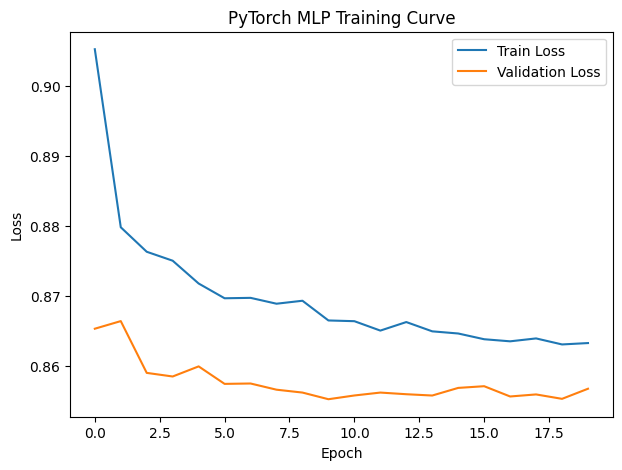

In [21]:
plt.figure(figsize=(7, 5))

plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PyTorch MLP Training Curve")
plt.legend()
plt.show()

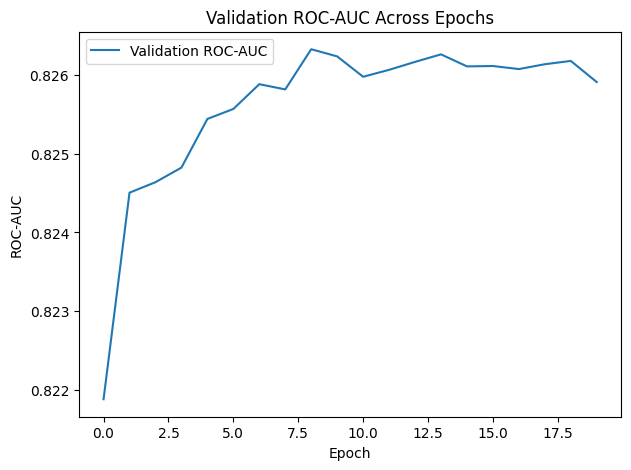

In [22]:
plt.figure(figsize=(7, 5))

plt.plot(history["val_roc_auc"], label="Validation ROC-AUC")

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("Validation ROC-AUC Across Epochs")
plt.legend()
plt.show()

The training and validation loss curves remain relatively stable after the first few epochs, suggesting that the model is learning without strong signs of overfitting.

Validation ROC-AUC improves early in training and then plateaus around 0.826, indicating that most of the useful ranking performance is learned within the first several epochs.

## Validation Threshold Tuning

The default threshold of 0.5 may not be optimal for the PyTorch model.

Three threshold strategies are compared:

1. **Default threshold**  
   The standard threshold of 0.5.

2. **Youden threshold**  
   Youden's J statistic selects the threshold where the true positive rate exceeds the false positive rate by the largest margin. This provides a general discrimination-oriented operating point.

3. **Recall-targeted threshold**  
   Because this project is framed as a preventative clinical screening task, recall is especially important. A second threshold is selected to achieve at least 0.85 recall on the validation set while minimizing the false positive rate among thresholds that satisfy this recall constraint.

The 0.85 recall target is used as an experimental screening-oriented operating point, not as a clinically validated requirement. It reflects the project goal of prioritizing sensitivity and reducing false negatives while still controlling false positives as much as possible.

This allows the model to be evaluated under standard, discrimination-oriented, and recall-oriented decision rules.

The held-out test set is not used during threshold selection.

In [23]:
fpr, tpr, thresholds = roc_curve(val_targets, val_probs)

# Youden's J selects the threshold where TPR exceeds FPR by the largest margin
youden_j = tpr - fpr
youden_idx = np.argmax(youden_j)
youden_threshold = thresholds[youden_idx]

print(round(youden_threshold, 3))

0.521


In [24]:
target_recall = 0.85

# Find thresholds that achieve at least the target recall on the validation set
valid_indices = np.where(tpr >= target_recall)[0]

if len(valid_indices) > 0:
    # Among thresholds satisfying the recall constraint, choose the one with the lowest FPR
    recall_target_idx = valid_indices[np.argmin(fpr[valid_indices])]
    recall_target_threshold = thresholds[recall_target_idx]
else:
    # Fallback to Youden threshold if the target recall cannot be achieved
    recall_target_idx = youden_idx
    recall_target_threshold = youden_threshold

print(round(recall_target_threshold, 3))

0.432


In [25]:
val_pred_default = (val_probs >= 0.5).astype(int)
val_pred_youden = (val_probs >= youden_threshold).astype(int)
val_pred_recall_targeted = (val_probs >= recall_target_threshold).astype(int)

metrics_val_default = evaluate_predictions(
    y_true=val_targets,
    y_pred=val_pred_default,
    y_proba=val_probs
)

metrics_val_youden = evaluate_predictions(
    y_true=val_targets,
    y_pred=val_pred_youden,
    y_proba=val_probs
)

metrics_val_recall_targeted = evaluate_predictions(
    y_true=val_targets,
    y_pred=val_pred_recall_targeted,
    y_proba=val_probs
)

metrics_val_comparison = pd.DataFrame({
    "Validation Default Threshold": metrics_val_default,
    "Validation Youden Threshold": metrics_val_youden,
    "Validation Recall-Targeted Threshold": metrics_val_recall_targeted
})

metrics_val_comparison


,Validation Default Threshold,Validation Youden Threshold,Validation Recall-Targeted Threshold
Accuracy,0.7176,0.7315,0.6774
Precision,0.3333,0.3440,0.3094
Recall,0.7917,0.7761,0.8501
F1,0.4691,0.4767,0.4537
ROC-AUC,0.8259,0.8259,0.8259


The validation results show three different operating points for the same PyTorch MLP probability outputs.

The default threshold achieves a recall of 0.7917, while the Youden threshold slightly improves accuracy, precision, and F1-score, but reduces recall to 0.7761. This suggests that the Youden threshold provides a more balanced discrimination-oriented decision rule, but it is not the most recall-sensitive option.

The recall-targeted threshold increases recall to 0.8501, meeting the experimental screening-oriented recall target. This comes with lower accuracy, precision, and F1-score, which reflects the expected trade-off in preventative screening: identifying more at-risk individuals usually increases false positives.

Because this project prioritizes sensitivity in a clinical screening context, the recall-targeted threshold is useful for evaluating how the model behaves when false negatives are treated as more costly than false positives.

In [26]:
print("Validation Classification Report - Recall-Targeted Threshold \n", 
      classification_report(val_targets, val_pred_recall_targeted))

Validation Classification Report - Recall-Targeted Threshold 
               precision    recall  f1-score   support

         0.0       0.96      0.65      0.77     34193
         1.0       0.31      0.85      0.45      6396

    accuracy                           0.68     40589
   macro avg       0.63      0.75      0.61     40589
weighted avg       0.86      0.68      0.72     40589



In [27]:
val_confusion_matrix_recall_targeted = pd.DataFrame(
    confusion_matrix(val_targets, val_pred_recall_targeted),
    index=["Actual Non-Risk", "Actual At-Risk"],
    columns=["Predicted Non-Risk", "Predicted At-Risk"]
)

print("Validation Confusion Matrix - Recall-Targeted Threshold")
val_confusion_matrix_recall_targeted

Validation Confusion Matrix - Recall-Targeted Threshold


,Predicted Non-Risk,Predicted At-Risk
Actual Non-Risk,22056,12137
Actual At-Risk,959,5437


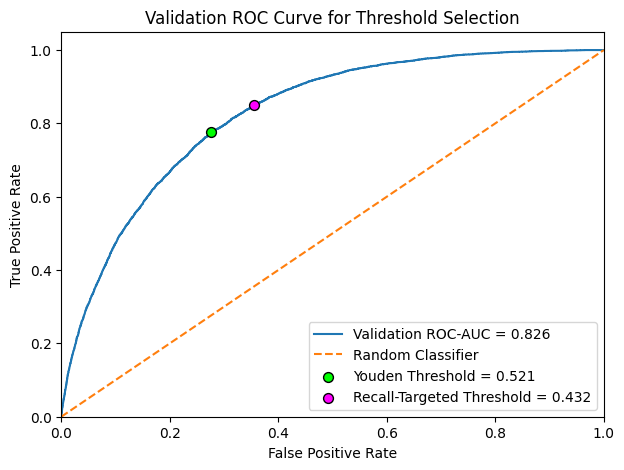

In [28]:
val_roc_auc = roc_auc_score(val_targets, val_probs)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"Validation ROC-AUC = {val_roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.scatter(
    fpr[youden_idx],
    tpr[youden_idx],
    label=f"Youden Threshold = {youden_threshold:.3f}",
    c='lime',
    zorder=3,
    s=50,
    edgecolors='black'
)

plt.scatter(
    fpr[recall_target_idx],
    tpr[recall_target_idx],
    label=f"Recall-Targeted Threshold = {recall_target_threshold:.3f}",
    c='magenta',
    zorder=3,
    s=50,
    edgecolors='black'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curve for Threshold Selection")
plt.axis([0, 1, 0, 1.05])
plt.legend()
plt.show()

The validation-selected thresholds define different operating modes for the final test evaluation.

All three thresholds will be applied to the held-out test set. The recall-targeted threshold will be emphasized as the screening-oriented decision rule, while the default and Youden thresholds provide standard and discrimination-oriented comparison points.

## Final Test Evaluation

The three threshold strategies are now applied to the held-out test set for final model evaluation.

This step measures how the PyTorch MLP generalizes under standard, Youden-based, and recall-oriented decision rules.

In [29]:
test_loss, test_probs, test_targets = evaluate_model(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    device=device
)

test_pred_default = (test_probs >= 0.5).astype(int)
test_pred_youden = (test_probs >= youden_threshold).astype(int)
test_pred_recall_targeted = (test_probs >= recall_target_threshold).astype(int)

metrics_test_default = evaluate_predictions(
    y_true=test_targets,
    y_pred=test_pred_default,
    y_proba=test_probs
)

metrics_test_youden = evaluate_predictions(
    y_true=test_targets,
    y_pred=test_pred_youden,
    y_proba=test_probs
)

metrics_test_recall_targeted = evaluate_predictions(
    y_true=test_targets,
    y_pred=test_pred_recall_targeted,
    y_proba=test_probs
)

metrics_test_comparison = pd.DataFrame({
    "PyTorch Default Threshold": metrics_test_default,
    "PyTorch Youden Threshold": metrics_test_youden,
    "PyTorch Recall-Targeted Threshold": metrics_test_recall_targeted
})

metrics_test_comparison

,PyTorch Default Threshold,PyTorch Youden Threshold,PyTorch Recall-Targeted Threshold
Accuracy,0.7191,0.7317,0.6750
Precision,0.3343,0.3435,0.3069
Recall,0.7895,0.7714,0.8447
F1,0.4697,0.4753,0.4503
ROC-AUC,0.8242,0.8242,0.8242


The test results show that the PyTorch MLP generalizes consistently across the three threshold strategies.

The default threshold achieves a recall of 0.7895 and provides a standard reference point. The Youden threshold slightly improves accuracy, precision, and F1-score, but reduces recall to 0.7714. This suggests that the Youden threshold produces a more balanced decision rule, but it is less sensitive to at-risk individuals.

The recall-targeted threshold increases recall to 0.8447, making it the most sensitive screening-oriented option among the three thresholds. This comes with lower accuracy, precision, and F1-score, which reflects the expected clinical screening trade-off: identifying more at-risk individuals usually increases false positives.

ROC-AUC remains unchanged at 0.8242 across all thresholds because threshold selection does not change the model's probability ranking. It only changes how predicted probabilities are converted into binary class labels.

In [30]:
print("Test Classification Report - Recall-Targeted Threshold \n", 
      classification_report(test_targets, test_pred_recall_targeted))

Test Classification Report - Recall-Targeted Threshold 
               precision    recall  f1-score   support

         0.0       0.96      0.64      0.77     42741
         1.0       0.31      0.84      0.45      7995

    accuracy                           0.67     50736
   macro avg       0.63      0.74      0.61     50736
weighted avg       0.85      0.67      0.72     50736



In [31]:
test_confusion_matrix_recall_targeted = pd.DataFrame(
    confusion_matrix(test_targets, test_pred_recall_targeted),
    index=["Actual Non-Risk", "Actual At-Risk"],
    columns=["Predicted Non-Risk", "Predicted At-Risk"]
)

print("Test Confusion Matrix - Recall-Targeted Threshold")
test_confusion_matrix_recall_targeted

Test Confusion Matrix - Recall-Targeted Threshold


,Predicted Non-Risk,Predicted At-Risk
Actual Non-Risk,27493,15248
Actual At-Risk,1242,6753


## Save Trained Model

The trained PyTorch model parameters are saved as a `state_dict`.

Only the learned weights and biases are saved, not the full model class definition. This is the recommended lightweight approach when the model architecture can be recreated in code.

In [32]:
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "pytorch_mlp_state_dict.pt"

torch.save(model.state_dict(), MODEL_PATH)

print(f"Model state_dict saved to: {MODEL_PATH}")

Model state_dict saved to: ..\models\pytorch_mlp_state_dict.pt


## PyTorch MLP Summary

This notebook implemented a PyTorch multilayer perceptron for binary diabetes risk prediction using the same target definition, train/test split, preprocessing strategy, and evaluation metrics as the scikit-learn baseline.

The model was trained with class-weighted `BCEWithLogitsLoss` to address class imbalance. This gave higher penalty to mistakes on the minority at-risk class and encouraged the model to prioritize sensitivity.

The PyTorch MLP achieved a test ROC-AUC of 0.8242, showing that the model learned useful probability rankings for distinguishing at-risk and non-risk individuals.

Three threshold strategies were compared:

- A default threshold of 0.5
- A Youden threshold that maximizes the difference between true positive rate and false positive rate
- A recall-targeted threshold designed for preventative screening by enforcing at least 0.85 validation recall

On the held-out test set, the recall-targeted threshold achieved the highest recall at 0.8447. This makes it the most sensitive screening-oriented operating point among the three thresholds.

This improvement in recall came with lower precision, accuracy, and F1-score, reflecting the expected trade-off in preventative clinical screening: identifying more at-risk individuals usually increases false positives.

The 0.85 recall target is not a clinically validated requirement. It is used as an experimental screening-oriented operating point to evaluate how the model behaves when sensitivity is prioritized.

The next step is to compare model reliability more deeply using calibration curves, Brier score, and uncertainty-aware evaluation.